In [ ]:
#Use all 4 Halo channels: O1, O2, Fp2, Fp1 clean/filter them safely run 4-channel ICA compare respiration-band EEG/ICA to BI

In [1]:
# Cell 1 — Imports

import sqlite3
from io import BytesIO
import json
import os
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt, detrend, welch
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import interp1d
from scipy.stats import pearsonr

import mne
from mne.preprocessing import ICA

print("Cell 1 complete: imports loaded")

Cell 1 complete: imports loaded


In [2]:
# Cell 2 — File paths

# EEG SQLite database file
eeg_db_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db"

# EmotiBit CSV file
ppg_csv_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686.csv"

# EmotiBit metadata JSON
info_json_path = "/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686_info.json"

# EEG sampling rate
fs_eeg = 250

print("Cell 2 complete: paths set")

print("\nEEG DB:")
print(eeg_db_path)

print("\nPPG CSV:")
print(ppg_csv_path)

print("\nEmotiBit JSON:")
print(info_json_path)

print("\nEEG sampling rate:")
print(fs_eeg)

Cell 2 complete: paths set

EEG DB:
/Users/sarah-rosemay/Documents/EEG_data/Combo test/subj-1_ses-S001_task-breathing_ppg_sarah_test_run-001_20010128_225732_eeg.db

PPG CSV:
/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686.csv

EmotiBit JSON:
/Users/sarah-rosemay/Documents/EEG_data/Combo test/2026-04-27_11-49-02-823686_info.json

EEG sampling rate:
250


In [3]:
# Cell 3 — Load EEG database and inspect tables

conn = sqlite3.connect(eeg_db_path)

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Available tables:")
print(tables)

# Find EEG data table automatically
data_table = [t for t in tables["name"] if t.startswith("data_")][0]

print("\nUsing EEG data table:")
print(data_table)

# Table name needs quotes because it contains hyphens
df = pd.read_sql_query(f'SELECT * FROM "{data_table}"', conn)

print("\nLoaded EEG dataframe shape:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst rows:")
display(df.head())

Available tables:
                                               name
0         data_87d03f26-0f33-4e1d-a259-2181ccc29071
1         meta_87d03f26-0f33-4e1d-a259-2181ccc29071
2  annotations_87d03f26-0f33-4e1d-a259-2181ccc29071

Using EEG data table:
data_87d03f26-0f33-4e1d-a259-2181ccc29071

Loaded EEG dataframe shape:
(3772, 3)

Columns:
Index(['data', 'time', 'local_clock'], dtype='object')

First rows:


,data,time,local_clock
0,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...",2.415507e+06
1,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...",2.415508e+06
2,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...",2.415508e+06
3,"b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...","b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...",2.415508e+06
4,"b""\x93NUMPY\x01\x00v\x00{'descr': '<f8', 'fort...","b'\x93NUMPY\x01\x00v\x00{\'descr\': \'<f8\', \...",2.415508e+06


Number of EEG chunks: 3772

Cell 4 complete

Channel shapes:
O1 : (133600,)
O2 : (133600,)
Fp2: (133600,)
Fp1: (133600,)


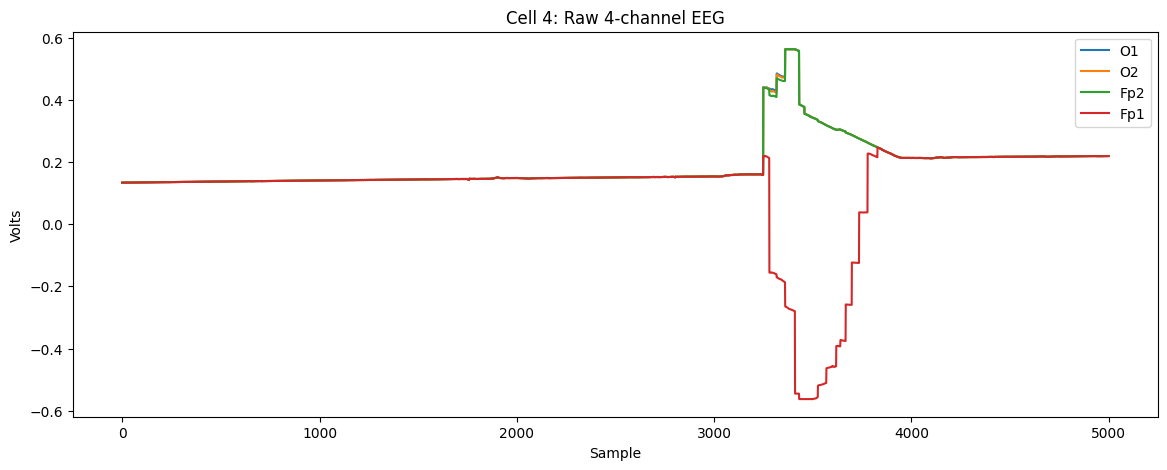

In [4]:
# Cell 4 — Extract O1, O2, Fp2, Fp1 EEG channels

# Expected channel order from Halo:
# O1, O2, Fp2, Fp1, Sample, Streaming, Battery

o1_list = []
o2_list = []
fp2_list = []
fp1_list = []

print("Number of EEG chunks:", len(df))

for i, row in df.iterrows():

    try:
        # Convert byte blob back into numpy array
        chunk = np.load(
            BytesIO(row["data"]),
            allow_pickle=True
        )

        # Extract channels
        o1_list.append(chunk[0])
        o2_list.append(chunk[1])
        fp2_list.append(chunk[2])
        fp1_list.append(chunk[3])

    except Exception as e:
        print(f"Skipping chunk {i} because of error:")
        print(e)

# Concatenate chunks
o1 = np.concatenate(o1_list)
o2 = np.concatenate(o2_list)
fp2 = np.concatenate(fp2_list)
fp1 = np.concatenate(fp1_list)

# Convert microvolts -> volts
o1 = o1 / 1e6
o2 = o2 / 1e6
fp2 = fp2 / 1e6
fp1 = fp1 / 1e6

print("\nCell 4 complete")

print("\nChannel shapes:")
print("O1 :", o1.shape)
print("O2 :", o2.shape)
print("Fp2:", fp2.shape)
print("Fp1:", fp1.shape)

# Quick visualization
plt.figure(figsize=(14,5))

plt.plot(o1[:5000], label="O1")
plt.plot(o2[:5000], label="O2")
plt.plot(fp2[:5000], label="Fp2")
plt.plot(fp1[:5000], label="Fp1")

plt.title("Cell 4: Raw 4-channel EEG")
plt.xlabel("Sample")
plt.ylabel("Volts")

plt.legend()
plt.show()

Cell 5 complete
O1 finite: 133600 / 133600
O1 std: 0.032172798784082524
O2 finite: 133600 / 133600
O2 std: 0.03492894022502185
Fp2 finite: 133600 / 133600
Fp2 std: 0.00439776804928903
Fp1 finite: 133600 / 133600
Fp1 std: 0.028035434537863942


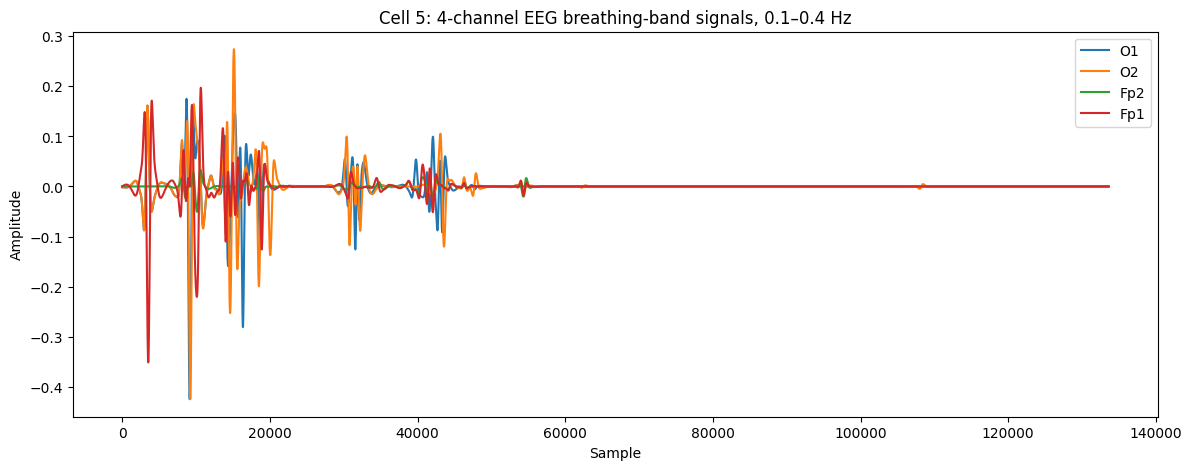

In [5]:
# Cell 5 — Clean and filter all 4 EEG channels

# This cell:
# 1. removes NaNs/infs
# 2. interpolates over bad samples
# 3. removes extreme spikes
# 4. filters each channel into the respiration band: 0.1–0.4 Hz

def clean_signal_before_filter(x):
    x = np.asarray(x, dtype=float)

    # Replace bad values with NaN
    x[~np.isfinite(x)] = np.nan

    # Interpolate over NaNs
    good = np.isfinite(x)

    if good.sum() < 10:
        raise ValueError("Not enough good EEG samples to filter.")

    x[~good] = np.interp(
        np.flatnonzero(~good),
        np.flatnonzero(good),
        x[good]
    )

    # Remove extreme spikes using robust median/MAD
    med = np.median(x)
    mad = np.median(np.abs(x - med))

    if mad > 0:
        robust_z = 0.6745 * (x - med) / mad
        bad = np.abs(robust_z) > 20

        if bad.sum() > 0 and (~bad).sum() > 10:
            x[bad] = np.interp(
                np.flatnonzero(bad),
                np.flatnonzero(~bad),
                x[~bad]
            )

    return x


def safe_bandpass(x, low, high, fs, order=2):
    x = clean_signal_before_filter(x)
    x = x - np.mean(x)

    sos = butter(
        order,
        [low, high],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    y = sosfiltfilt(sos, x)
    y[~np.isfinite(y)] = np.nan

    return y


# Clean raw channels
o1_clean = clean_signal_before_filter(o1)
o2_clean = clean_signal_before_filter(o2)
fp2_clean = clean_signal_before_filter(fp2)
fp1_clean = clean_signal_before_filter(fp1)

# Filter into breathing band
o1_breath = safe_bandpass(o1_clean, 0.1, 0.4, fs_eeg)
o2_breath = safe_bandpass(o2_clean, 0.1, 0.4, fs_eeg)
fp2_breath = safe_bandpass(fp2_clean, 0.1, 0.4, fs_eeg)
fp1_breath = safe_bandpass(fp1_clean, 0.1, 0.4, fs_eeg)

print("Cell 5 complete")

for name, sig in {
    "O1": o1_breath,
    "O2": o2_breath,
    "Fp2": fp2_breath,
    "Fp1": fp1_breath,
}.items():
    print(f"{name} finite:", np.isfinite(sig).sum(), "/", len(sig))
    print(f"{name} std:", np.nanstd(sig))

plt.figure(figsize=(14,5))

plt.plot(o1_breath, label="O1")
plt.plot(o2_breath, label="O2")
plt.plot(fp2_breath, label="Fp2")
plt.plot(fp1_breath, label="Fp1")

plt.title("Cell 5: 4-channel EEG breathing-band signals, 0.1–0.4 Hz")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.legend()
plt.show()

In [6]:
# Cell 6 — Load EmotiBit CSV and inspect labels

ppg = pd.read_csv(
    ppg_csv_path,
    engine="python",
    header=None,
    on_bad_lines="skip"
)

print("Cell 6 complete")
print("PPG shape:", ppg.shape)

print("\nEvent/type labels in column 3:")
print(ppg[3].value_counts().head(30))

bi = ppg[ppg[3] == "BI"].copy()

print("\nBI rows:", bi.shape)
display(bi.head())

Cell 6 complete
PPG shape: (23793, 7)

Event/type labels in column 3:
3
TH    5944
T1    5923
EL    3632
EA    3632
SF    2408
HR     537
BI     537
TL     312
SA     269
SR     269
B%     160
BV     160
RB       1
MY       1
MX       1
GZ       1
GY       1
GX       1
AZ       1
AY       1
AX       1
MZ       1
Name: count, dtype: int64

BI rows: (537, 7)


,0,1,2,3,4,5,6
184,260215,38728,1,BI,1,100,7990
226,261638,38961,1,BI,1,100,1420
239,261988,39028,1,BI,1,100,350
255,262481,39098,1,BI,1,100,490
275,263121,39204,1,BI,1,100,640


Cell 7 complete
Clean BI count: 419
BI min sec: 0.31
BI max sec: 1.98
BI std sec: 0.4139939657733199


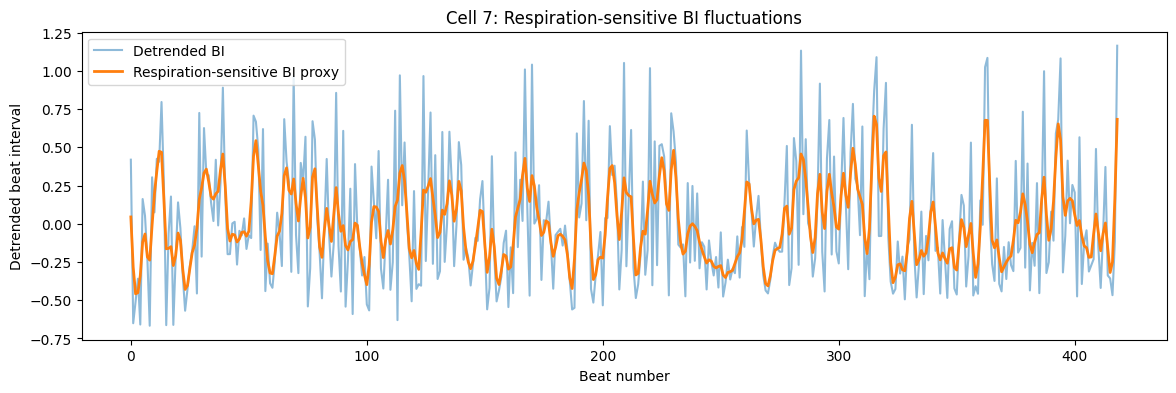

In [7]:
# Cell 7 — Build respiration-sensitive BI fluctuation signal

# BI = beat interval between heartbeats.
# Respiration influences short-timescale HRV
# through respiratory sinus arrhythmia (RSA).
#
# We:
# 1. convert BI to seconds
# 2. remove impossible values
# 3. detrend slow drift
# 4. lightly smooth
#
# Goal:
# preserve respiration-scale fluctuations (~0.1–0.4 Hz)

# Extract BI values
bi_vals_ms = pd.to_numeric(
    bi[6],
    errors="coerce"
).values

# Convert milliseconds -> seconds
bi_vals_sec = bi_vals_ms / 1000.0

# Remove impossible values
bi_vals_sec = bi_vals_sec[np.isfinite(bi_vals_sec)]

bi_vals_sec = bi_vals_sec[
    (bi_vals_sec > 0.3) &
    (bi_vals_sec < 2.0)
]

# Remove slow drift
bi_detrended = detrend(bi_vals_sec)

# Light smoothing only
bi_proxy = gaussian_filter1d(
    bi_detrended,
    sigma=1
)

print("Cell 7 complete")

print("Clean BI count:", len(bi_vals_sec))
print("BI min sec:", np.min(bi_vals_sec))
print("BI max sec:", np.max(bi_vals_sec))
print("BI std sec:", np.std(bi_vals_sec))

# Plot
plt.figure(figsize=(14,4))

plt.plot(
    bi_detrended,
    label="Detrended BI",
    alpha=0.5
)

plt.plot(
    bi_proxy,
    label="Respiration-sensitive BI proxy",
    linewidth=2
)

plt.title("Cell 7: Respiration-sensitive BI fluctuations")
plt.xlabel("Beat number")
plt.ylabel("Detrended beat interval")

plt.legend()
plt.show()

Cell 8 complete
EEG duration sec: 534.396
EEG samples: 133600
BI proxy samples: 419
BI-on-EEG samples: 133600


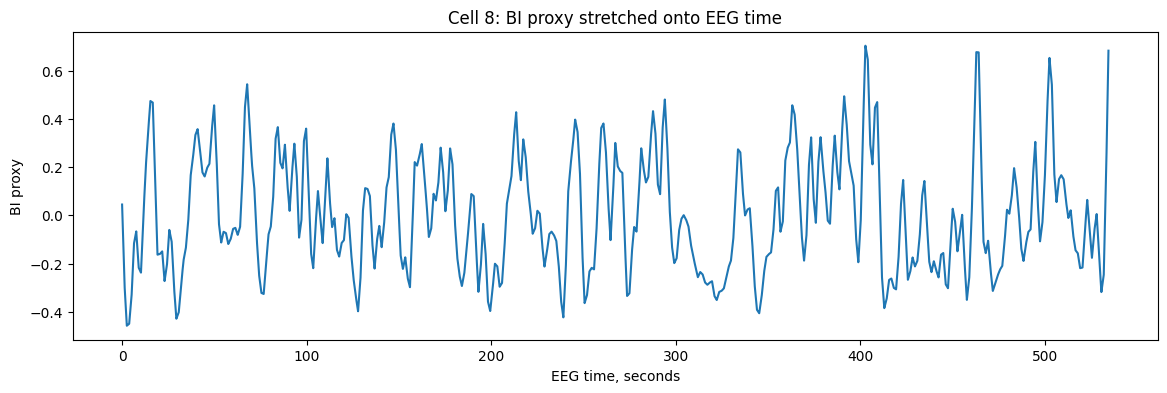

In [8]:
# Cell 8 — Interpolate BI proxy onto EEG sample time

# EEG is sampled regularly at 250 Hz.
# BI is sampled irregularly, once per heartbeat.
#
# For this first comparison, we stretch the BI proxy across
# the full EEG recording duration so both signals have the same length.
#
# This is not perfect physiological synchronization.
# It is a first-pass comparison.

# Create EEG time axis in seconds
eeg_time = np.arange(len(fp1_breath)) / fs_eeg

# Create BI time axis stretched across the same duration
bi_time_stretched = np.linspace(
    eeg_time[0],
    eeg_time[-1],
    len(bi_proxy)
)

# Interpolate BI proxy onto EEG time
interp_func = interp1d(
    bi_time_stretched,
    bi_proxy,
    kind="linear",
    bounds_error=False,
    fill_value="extrapolate"
)

bi_on_eeg_time = interp_func(eeg_time)

print("Cell 8 complete")
print("EEG duration sec:", eeg_time[-1])
print("EEG samples:", len(eeg_time))
print("BI proxy samples:", len(bi_proxy))
print("BI-on-EEG samples:", len(bi_on_eeg_time))

plt.figure(figsize=(14, 4))
plt.plot(eeg_time, bi_on_eeg_time)
plt.title("Cell 8: BI proxy stretched onto EEG time")
plt.xlabel("EEG time, seconds")
plt.ylabel("BI proxy")
plt.show()

Cell 9 diagnostics
EEG samples: 133600
BI samples: 133600
Valid paired samples: 133600
EEG std: 1.0
BI std: 0.9999999999999999

Cell 9 result
Zero-lag correlation: r = 0.028, p = 3.32e-24


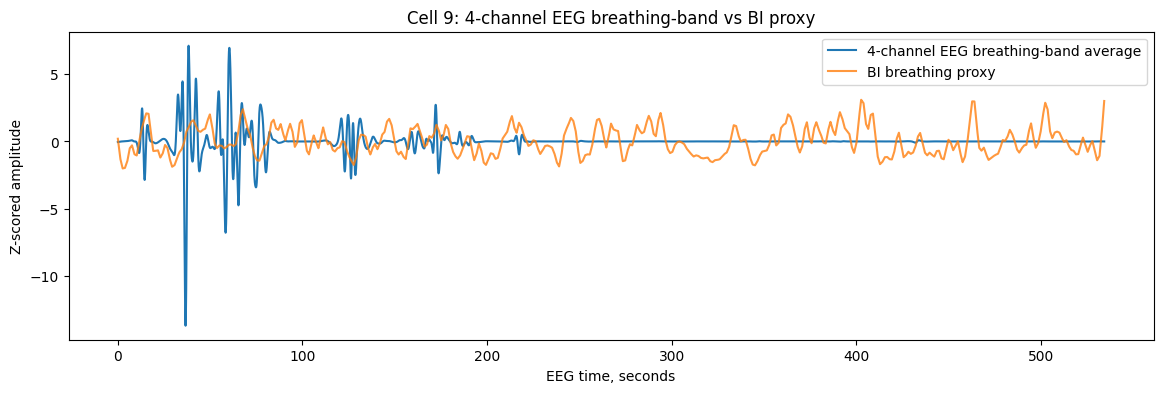

In [9]:
# Cell 9 — Compare 4-channel EEG breathing-band average to BI proxy

# This creates a simple respiration-band EEG proxy
# by averaging all four breathing-band channels:
# O1, O2, Fp2, Fp1.
#
# Then it compares that EEG proxy to the BI-derived physiology proxy.

def zscore_safe(x):
    x = np.asarray(x, dtype=float)
    x[~np.isfinite(x)] = np.nan

    mean = np.nanmean(x)
    std = np.nanstd(x)

    if not np.isfinite(std) or std == 0:
        return np.full_like(x, np.nan)

    return (x - mean) / std


# Average all four respiration-band EEG channels
eeg_resp_4ch = (
    o1_breath +
    o2_breath +
    fp2_breath +
    fp1_breath
) / 4

# Z-score both signals
eeg_resp_4ch_z = zscore_safe(eeg_resp_4ch)
bi_resp_z = zscore_safe(bi_on_eeg_time)

# Valid paired samples
valid = np.isfinite(eeg_resp_4ch_z) & np.isfinite(bi_resp_z)

print("Cell 9 diagnostics")
print("EEG samples:", len(eeg_resp_4ch_z))
print("BI samples:", len(bi_resp_z))
print("Valid paired samples:", valid.sum())
print("EEG std:", np.nanstd(eeg_resp_4ch_z))
print("BI std:", np.nanstd(bi_resp_z))

if valid.sum() < 2:
    print("\nERROR: Not enough valid paired samples for correlation.")
else:
    r, p = pearsonr(
        eeg_resp_4ch_z[valid],
        bi_resp_z[valid]
    )

    print("\nCell 9 result")
    print(f"Zero-lag correlation: r = {r:.3f}, p = {p:.3g}")

    plt.figure(figsize=(14, 4))

    plt.plot(
        eeg_time[valid],
        eeg_resp_4ch_z[valid],
        label="4-channel EEG breathing-band average"
    )

    plt.plot(
        eeg_time[valid],
        bi_resp_z[valid],
        label="BI breathing proxy",
        alpha=0.8
    )

    plt.title("Cell 9: 4-channel EEG breathing-band vs BI proxy")
    plt.xlabel("EEG time, seconds")
    plt.ylabel("Z-scored amplitude")

    plt.legend()
    plt.show()

In [10]:
# Cell 10 — Load EmotiBit metadata JSON

# The JSON file describes available sensor streams,
# channel tags, sample rates, and firmware configuration.

with open(info_json_path, "r") as f:
    emotibit_info = json.load(f)

print("Cell 10 complete")

print("\nSignals listed in EmotiBit JSON:\n")

for item in emotibit_info:

    info = item.get("info", {})

    name = info.get("name")
    sig_type = info.get("type")
    tags = info.get("typeTags")
    rate = info.get("nominal_srate", "not listed")
    units = info.get("units", "not listed")

    print(
        f"{name} | "
        f"type={sig_type} | "
        f"tags={tags} | "
        f"srate={rate} | "
        f"units={units}"
    )

print("\nLabels actually present in loaded CSV:")
print(sorted(ppg[3].dropna().unique()))

Cell 10 complete

Signals listed in EmotiBit JSON:

EmotiBitData | type=Multimodal | tags=None | srate=not listed | units=not listed
Accelerometer | type=Accelerometer | tags=['AX', 'AY', 'AZ'] | srate=25 | units=g
Gyroscope | type=Gyroscope | tags=['GX', 'GY', 'GZ'] | srate=25 | units=degrees/second
Magnetometer | type=Magnetometer | tags=['MX', 'MY', 'MZ'] | srate=25 | units=microhenries
ElectrodermalActivity | type=ElectrodermalActivity | tags=['EA'] | srate=15 | units=microsiemens
SkinConductanceResponseAmplitude | type=ElectrodermalActivity | tags=['SA'] | srate=not listed | units=microsiemens
SkinConductanceResponseFrequency | type=ElectrodermalActivity | tags=['SF'] | srate=3 | units=count/min
SkinConductanceResponseRiseTime | type=ElectrodermalActivity | tags=['SR'] | srate=not listed | units=secs
Temperature1 | type=Temperature | tags=['T1'] | srate=7.5 | units=degrees celcius
Thermopile | type=Temperature | tags=['TH'] | srate=7.5 | units=degrees celcius
PPG | type=PPG | tags

Creating RawArray with float64 data, n_channels=4, n_times=133600
    Range : 0 ... 133599 =      0.000 ...   534.396 secs
Ready.
Fitting ICA to data using 4 channels (please be patient, this may take a while)
Selecting by number: 3 components
Fitting ICA took 0.2s.
Cell 11 complete
ICA sources shape: (3, 133600)


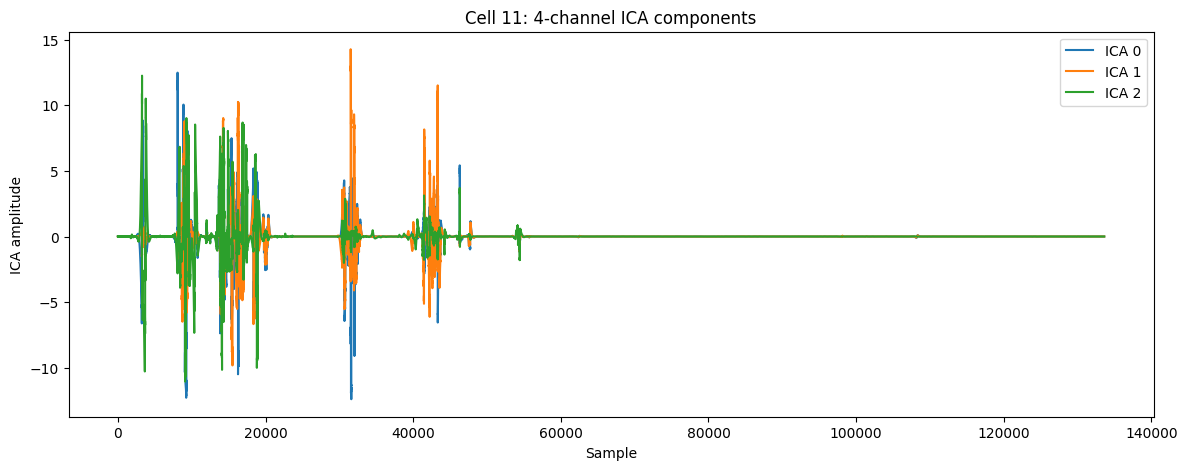

In [11]:
# Cell 11 — Run ICA on all 4 EEG channels

# Using all four Halo channels:
# - O1
# - O2
# - Fp2
# - Fp1
#
# 4-channel ICA is more meaningful than 2-channel ICA because
# there is more spatial information available for source separation.

# Stack channels into MNE format
# shape = channels x samples
eeg_clean_4ch = np.vstack([
    o1_clean,
    o2_clean,
    fp2_clean,
    fp1_clean
])

# Create MNE info structure
info = mne.create_info(
    ch_names=["O1", "O2", "Fp2", "Fp1"],
    sfreq=fs_eeg,
    ch_types=["eeg"] * 4
)

# Create Raw object
raw_clean = mne.io.RawArray(
    eeg_clean_4ch,
    info
)

# ICA should be fit on broader-band EEG
raw_for_ica = raw_clean.copy()

raw_for_ica.filter(
    0.5,
    40,
    verbose=False
)

# Use 3 ICA components
# (often more stable than full-rank 4-component ICA)
ica = ICA(
    n_components=3,
    random_state=97,
    max_iter="auto"
)

ica.fit(raw_for_ica)

# Extract ICA source signals
sources_raw = ica.get_sources(raw_for_ica)
sources = sources_raw.get_data()

print("Cell 11 complete")
print("ICA sources shape:", sources.shape)

# Plot ICA components
plt.figure(figsize=(14,5))

for i in range(sources.shape[0]):

    plt.plot(
        sources[i],
        label=f"ICA {i}"
    )

plt.title("Cell 11: 4-channel ICA components")
plt.xlabel("Sample")
plt.ylabel("ICA amplitude")

plt.legend()
plt.show()

Cell 12 results


,component,r,p
0,ICA 0,0.003511,0.199408
1,ICA 1,0.005901,0.031018
2,ICA 2,0.013215,0.000001



Best component: ICA 2
Best correlation: r = 0.013


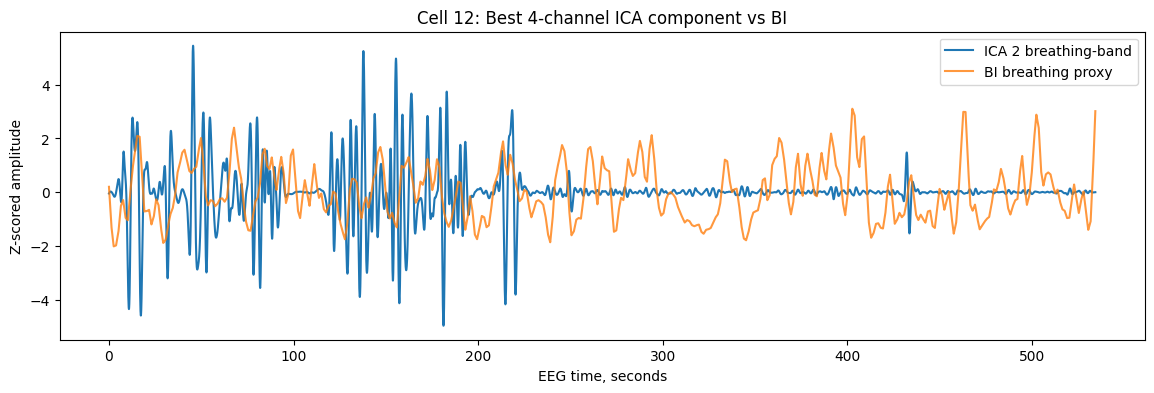

In [12]:
# Cell 12 — Compare 4-channel ICA components to BI proxy

# This tests whether any 4-channel ICA component matches the BI-derived
# respiration proxy better than the simple 4-channel average.

ica_breath_list = []
ica_z_list = []
ica_results = []

for i in range(sources.shape[0]):

    # Extract ICA component
    ic = sources[i]

    # Filter into breathing band
    ic_breath = safe_bandpass(ic, 0.1, 0.4, fs_eeg)

    # Z-score
    ic_z = zscore_safe(ic_breath)

    # Compare to BI
    valid = np.isfinite(ic_z) & np.isfinite(bi_resp_z)

    r, p = pearsonr(
        ic_z[valid],
        bi_resp_z[valid]
    )

    ica_breath_list.append(ic_breath)
    ica_z_list.append(ic_z)

    ica_results.append({
        "component": f"ICA {i}",
        "r": r,
        "p": p
    })

# Display results
ica_results_df = pd.DataFrame(ica_results)

print("Cell 12 results")
display(ica_results_df)

# Find best ICA component by absolute correlation
best_idx = np.argmax(np.abs(ica_results_df["r"].values))
best_component = best_idx
best_r = ica_results_df.loc[best_idx, "r"]

print(f"\nBest component: ICA {best_component}")
print(f"Best correlation: r = {best_r:.3f}")

# Plot best ICA component vs BI
plt.figure(figsize=(14,4))

plt.plot(
    eeg_time,
    ica_z_list[best_component],
    label=f"ICA {best_component} breathing-band"
)

plt.plot(
    eeg_time,
    bi_resp_z,
    label="BI breathing proxy",
    alpha=0.8
)

plt.title(f"Cell 12: Best 4-channel ICA component vs BI")
plt.xlabel("EEG time, seconds")
plt.ylabel("Z-scored amplitude")

plt.legend()
plt.show()

4-channel average
  Dominant freq: 0.317 Hz
  Breaths/min:   19.0

ICA 0
  Dominant freq: 0.150 Hz
  Breaths/min:   9.0

ICA 1
  Dominant freq: 0.150 Hz
  Breaths/min:   9.0

ICA 2
  Dominant freq: 0.283 Hz
  Breaths/min:   17.0

BI proxy
  Dominant freq: 0.050 Hz
  Breaths/min:   3.0



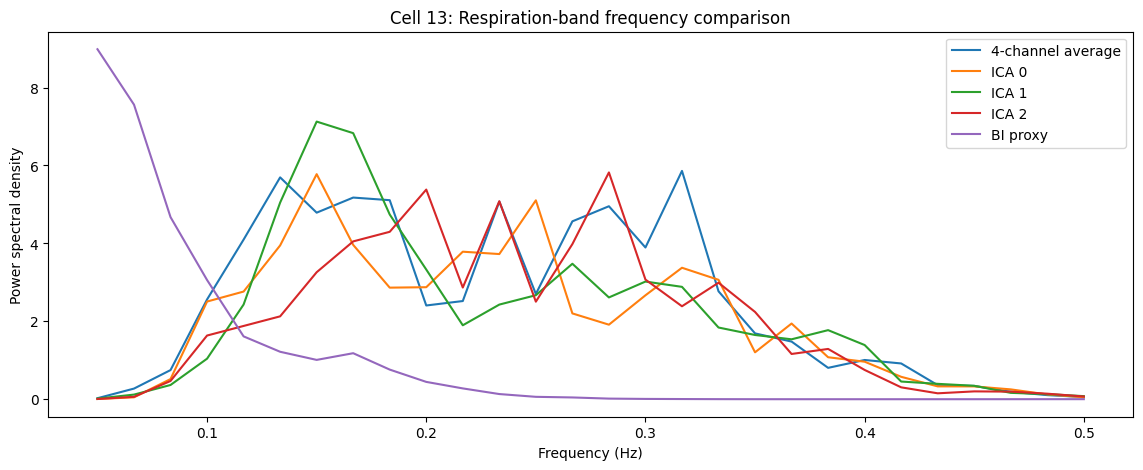

In [13]:
# Cell 13 — Frequency-domain comparison for 4-channel EEG and ICA

# This checks whether EEG and ICA components contain
# stable oscillatory structure in the respiration band.

def dominant_freq_in_band(x, fs, fmin=0.05, fmax=0.5):

    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]

    freqs, psd = welch(
        x,
        fs=fs,
        nperseg=min(len(x), fs * 60)
    )

    band = (freqs >= fmin) & (freqs <= fmax)

    dom_idx = np.argmax(psd[band])

    dom_freq = freqs[band][dom_idx]
    dom_power = psd[band][dom_idx]

    return freqs, psd, dom_freq, dom_power


signals = {
    "4-channel average": eeg_resp_4ch_z,
    "ICA 0": ica_z_list[0],
    "ICA 1": ica_z_list[1],
    "ICA 2": ica_z_list[2],
    "BI proxy": bi_resp_z,
}

results = {}

for name, sig in signals.items():

    freqs, psd, dom_freq, dom_power = dominant_freq_in_band(
        sig,
        fs=fs_eeg,
        fmin=0.05,
        fmax=0.5
    )

    results[name] = {
        "freqs": freqs,
        "psd": psd,
        "dom_freq": dom_freq,
        "dom_power": dom_power,
        "breaths_per_min": dom_freq * 60
    }

    print(f"{name}")
    print(f"  Dominant freq: {dom_freq:.3f} Hz")
    print(f"  Breaths/min:   {dom_freq * 60:.1f}")
    print()

# Plot spectra
plt.figure(figsize=(14,5))

for name, res in results.items():

    band = (
        (res["freqs"] >= 0.05) &
        (res["freqs"] <= 0.5)
    )

    plt.plot(
        res["freqs"][band],
        res["psd"][band],
        label=name
    )

plt.title("Cell 13: Respiration-band frequency comparison")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")

plt.legend()

plt.show()


ICA 0
O1: r = -0.010
O2: r = -0.005
Fp2: r = -0.046
Fp1: r = -0.087


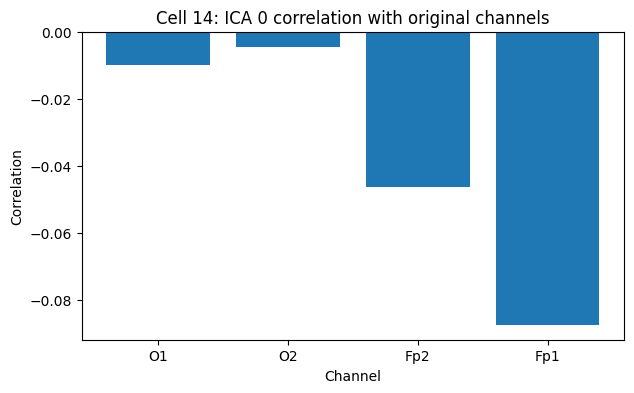


ICA 1
O1: r = 0.045
O2: r = 0.065
Fp2: r = 0.014
Fp1: r = 0.073


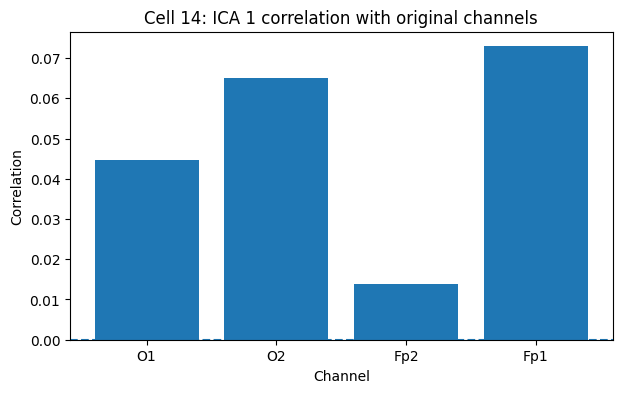


ICA 2
O1: r = -0.041
O2: r = -0.156
Fp2: r = 0.065
Fp1: r = -0.064


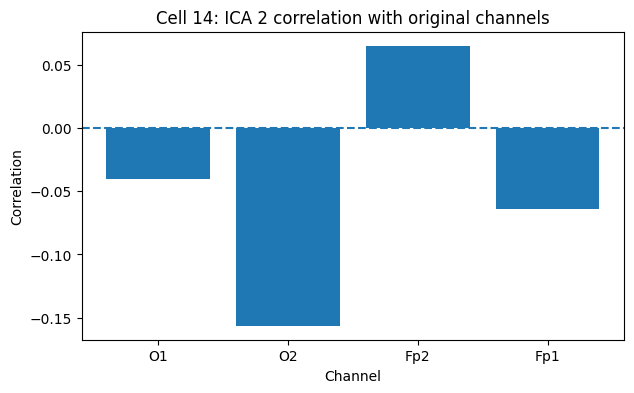


Component-channel correlation table:


,component,O1,O2,Fp2,Fp1
0,ICA 0,-0.009931,-0.004589,-0.046379,-0.087412
1,ICA 1,0.044580,0.065173,0.013797,0.072906
2,ICA 2,-0.040528,-0.156477,0.065409,-0.064101


In [19]:
# Cell 14 — Approximate ICA component channel contributions

# MNE topomap plotting can fail with very low-density custom data
# if sensor positions are missing.
#
# Instead, we estimate how much each ICA component relates to each
# original cleaned EEG channel by correlating:
# - each ICA component
# - with each cleaned EEG channel
#
# This is not a true ICA topography, but it is useful for interpretation.

channel_data = {
    "O1": o1_clean,
    "O2": o2_clean,
    "Fp2": fp2_clean,
    "Fp1": fp1_clean,
}

component_channel_corrs = []

for comp_idx in range(sources.shape[0]):

    comp = sources[comp_idx]

    print(f"\n====================")
    print(f"ICA {comp_idx}")
    print("====================")

    row = {"component": f"ICA {comp_idx}"}

    corrs = []

    for ch_name, ch_sig in channel_data.items():

        valid = np.isfinite(comp) & np.isfinite(ch_sig)

        r = np.corrcoef(
            comp[valid],
            ch_sig[valid]
        )[0, 1]

        row[ch_name] = r
        corrs.append(r)

        print(f"{ch_name}: r = {r:.3f}")

    component_channel_corrs.append(row)

    plt.figure(figsize=(7, 4))
    plt.bar(list(channel_data.keys()), corrs)
    plt.axhline(0, linestyle="--")
    plt.title(f"Cell 14: ICA {comp_idx} correlation with original channels")
    plt.xlabel("Channel")
    plt.ylabel("Correlation")
    plt.show()

component_channel_corrs_df = pd.DataFrame(component_channel_corrs)

print("\nComponent-channel correlation table:")
display(component_channel_corrs_df)

In [20]:
# Cell 15 — Save key 4-channel results summary

summary_results = pd.DataFrame({
    "signal": [
        "4-channel average",
        "ICA 0",
        "ICA 1",
        "ICA 2",
        "BI proxy"
    ],
    "dominant_freq_hz": [
        results["4-channel average"]["dom_freq"],
        results["ICA 0"]["dom_freq"],
        results["ICA 1"]["dom_freq"],
        results["ICA 2"]["dom_freq"],
        results["BI proxy"]["dom_freq"]
    ],
    "breaths_per_min": [
        results["4-channel average"]["breaths_per_min"],
        results["ICA 0"]["breaths_per_min"],
        results["ICA 1"]["breaths_per_min"],
        results["ICA 2"]["breaths_per_min"],
        results["BI proxy"]["breaths_per_min"]
    ],
    "interpretation": [
        "4-channel EEG average",
        "slow respiration-band ICA rhythm",
        "slow respiration-band ICA rhythm",
        "faster respiration-band ICA rhythm",
        "BI-derived physiology proxy"
    ]
})

display(summary_results)

summary_results.to_csv(
    "EEG_4ch_respiration_band_summary.csv",
    index=False
)

print("Saved: EEG_4ch_respiration_band_summary.csv")

,signal,dominant_freq_hz,breaths_per_min,interpretation
0,4-channel average,0.316667,19.0,4-channel EEG average
1,ICA 0,0.150000,9.0,slow respiration-band ICA rhythm
2,ICA 1,0.150000,9.0,slow respiration-band ICA rhythm
3,ICA 2,0.283333,17.0,faster respiration-band ICA rhythm
4,BI proxy,0.050000,3.0,BI-derived physiology proxy


Saved: EEG_4ch_respiration_band_summary.csv


# Interpretation checklist

Use this checklist before adding advanced analyses such as:
- PAC
- bycycle
- phase-locking
- cycle-by-cycle coupling
- waveform symmetry metrics


## Signal quality

- Does the EEG remain stable across the recording?
- Are there flat or low-variance sections?
- Are respiration-band filters stable without NaNs or exploding values?


## Respiration-band consistency

- Do EEG channels show stable low-frequency oscillations?
- Are dominant EEG spectral peaks within a plausible breathing range (~0.1–0.3 Hz)?
- Do multiple ICA components show reproducible respiration-band structure?


## Physiology comparison

- Do EEG and BI show similar dominant frequencies?
- Do the waveforms visually resemble each other?
- Does lagged correlation improve the relationship?
- Does ICA meaningfully improve the relationship over raw channel averages?


## Interpretation caution

- BI is an indirect respiration proxy, not true respiration.
- Weak BI coupling does not necessarily mean EEG lacks respiration-related structure.
- Consumer dry-electrode EEG may contain:
  - respiration-related neural activity
  - vascular activity
  - autonomic coupling
  - motion contamination
  - slow physiological artifacts


## Current notebook interpretation

This notebook showed:

- reproducible EEG respiration-band oscillations
- plausible breathing-range spectral peaks (~9–19 breaths/min)
- meaningful changes after adding all 4 channels
- ICA separation of multiple low-frequency rhythms

However:

- BI-derived respiration estimates remained weakly coupled to EEG
- ICA spatial interpretation remained limited due to low channel count
- direct respiration validation was not available


## Before advanced analyses

Only proceed to:
- PAC
- bycycle
- phase analyses
- cycle-by-cycle coupling

after:
- preprocessing is stable
- respiration-band peaks are reproducible
- physiology comparison signals are trustworthy
- direct respiration measurements are available if possible

# Summary

## Dataset

- BrainAccess Halo 4-channel EEG
  - O1
  - O2
  - Fp2
  - Fp1

- EmotiBit physiology export
  - BI
  - HR
  - EDA-related channels
  - metadata indicating PPG capability


## EEG preprocessing

The notebook implemented:

- EEG extraction from Halo SQLite database
- cleaning/interpolation of invalid samples
- robust outlier handling
- respiration-band filtering (0.1–0.4 Hz)
- 4-channel ICA using MNE


## EEG findings

Stable respiration-band oscillations were repeatedly observed across:
- raw channel averages
- ICA components
- multiple channel configurations

Observed dominant EEG frequencies included approximately:
- ~0.15 Hz (~9 breaths/min)
- ~0.18–0.20 Hz (~10–12 breaths/min)
- ~0.28–0.32 Hz (~17–19 breaths/min)

Several of these frequencies fall within physiologically plausible breathing ranges.


## ICA findings

Adding O1/O2 meaningfully changed the spectral structure of the EEG signals.

ICA separated multiple low-frequency rhythms, including:
- slower rhythms near ~9 breaths/min
- faster rhythms near ~17 breaths/min

However:
- ICA did not strongly improve EEG↔BI correlations
- ICA spatial interpretation remained limited due to low channel count and consumer dry-electrode data


## BI findings

Multiple BI-derived respiration proxy approaches were explored, including:

- smoothed BI fluctuations
- detrended BI fluctuations
- lagged EEG↔BI comparisons
- frequency-domain comparisons

Across approaches:

- EEG↔BI correlations remained weak
- lagged correlations also remained weak
- BI-derived dominant frequencies remained substantially slower than EEG respiration-band peaks

This suggests BI in this export may not provide a sufficiently direct or reliable respiration estimate for strong EEG coupling analysis.


## Main interpretation

This notebook demonstrates:

- stable preprocessing of low-density EEG
- reproducible respiration-band EEG oscillations
- meaningful spectral structure revealed by ICA
- successful EEG/physiology alignment workflow
- limitations of BI-derived respiration estimation in this dataset

The notebook supports the interpretation that:
- stable low-frequency EEG oscillations exist within plausible respiration ranges

but does not yet establish:
- a definitive respiration-related neural source
- strong direct EEG↔respiration coupling


## Future directions

Potential improvements include:

- raw PPG waveform export
- direct respiration recordings
- respiration belts
- ECG-derived respiration
- phase-based coupling analyses
- cycle-by-cycle waveform comparisons
- developmental/attention-related analyses
- higher-density EEG recordings